# Exploratory Data Analysis (EDA)

**Description:** 

Pre-processing and diagnostic evaluation of the spatio-temporal dataset for the incompressible Navier-Stokes equations. This notebook validates high-resolution data generated by the NekTar++ spectral/hp element framework for non-dimensional flow around cylinder [Raissi et al., 2019, p. 693].

**Author:** Marcel Wilanowicz  
**Date:** 2026-05-10 

### 1. Initial Analysis and Visualization

The dataset is sourced from the official repository accompanying the paper "Physics-informed neural networks" [Raissi et al., 2019]: 

https://github.com/maziarraissi/PINNs/tree/master/main/Data

The simulation follows a non-dimensional setup for incompressible flow past a circular cylinder, targeting $Re = \frac{u_{\infty} D}{\nu} = \frac{1 \times 1}{0.01} = 100$ [Raissi et al., 2019, p. 693].

"Assuming a non-dimensional free stream velocity $u_{\infty} = 1$, cylinder diameter $D = 1$, and kinematic viscosity $\nu = 0.01$, the system exhibits a periodic steady state behavior characterized by a asymmetrical vortex shedding pattern in the cylinder wake, known as the Kármán vortex street" 

In [ ]:
import scipy.io

# Relative path to the raw data
data_path_raw = '../data/raw/cylinder_nektar_wake.mat'
data_raw = scipy.io.loadmat(data_path_raw)

# Identifying key variables in data structure
print(f"Dictionary keys: {data_raw.keys()}")

Dictionary keys: dict_keys(['__header__', '__version__', '__globals__', 'X_star', 't', 'U_star', 'p_star'])


In [ ]:
# Extracting key data for inspection

X_star = data_raw['X_star']
t = data_raw['t']
U_star = data_raw['U_star']
p_star = data_raw['p_star']

print(f"X_star: {X_star.shape}")
print(f"t: {t.shape}")
print(f"U_star: {U_star.shape}")
print(f"p_star: {p_star.shape}")

X_star: (5000, 2)
t: (200, 1)
U_star: (5000, 2, 200)
p_star: (5000, 200)


In [20]:
import matplotlib.pyplot as plt

# Extracting spatial coordinates (x, y) normalized by cylinder diameter D = 1
x = data_raw['X_star'][:, 0]
y = data_raw['X_star'][:, 1]

frame_idx = 199

# Physical fields for incompressible fluid flow as denoted in Navier–Stokes equations in two 
# dimensions [Raissi et al., 2019, Eq. 15]
u = data_raw['U_star'][:, 0, frame_idx]
v = data_raw['U_star'][:, 1, frame_idx]
p = data_raw['p_star'][:, frame_idx]

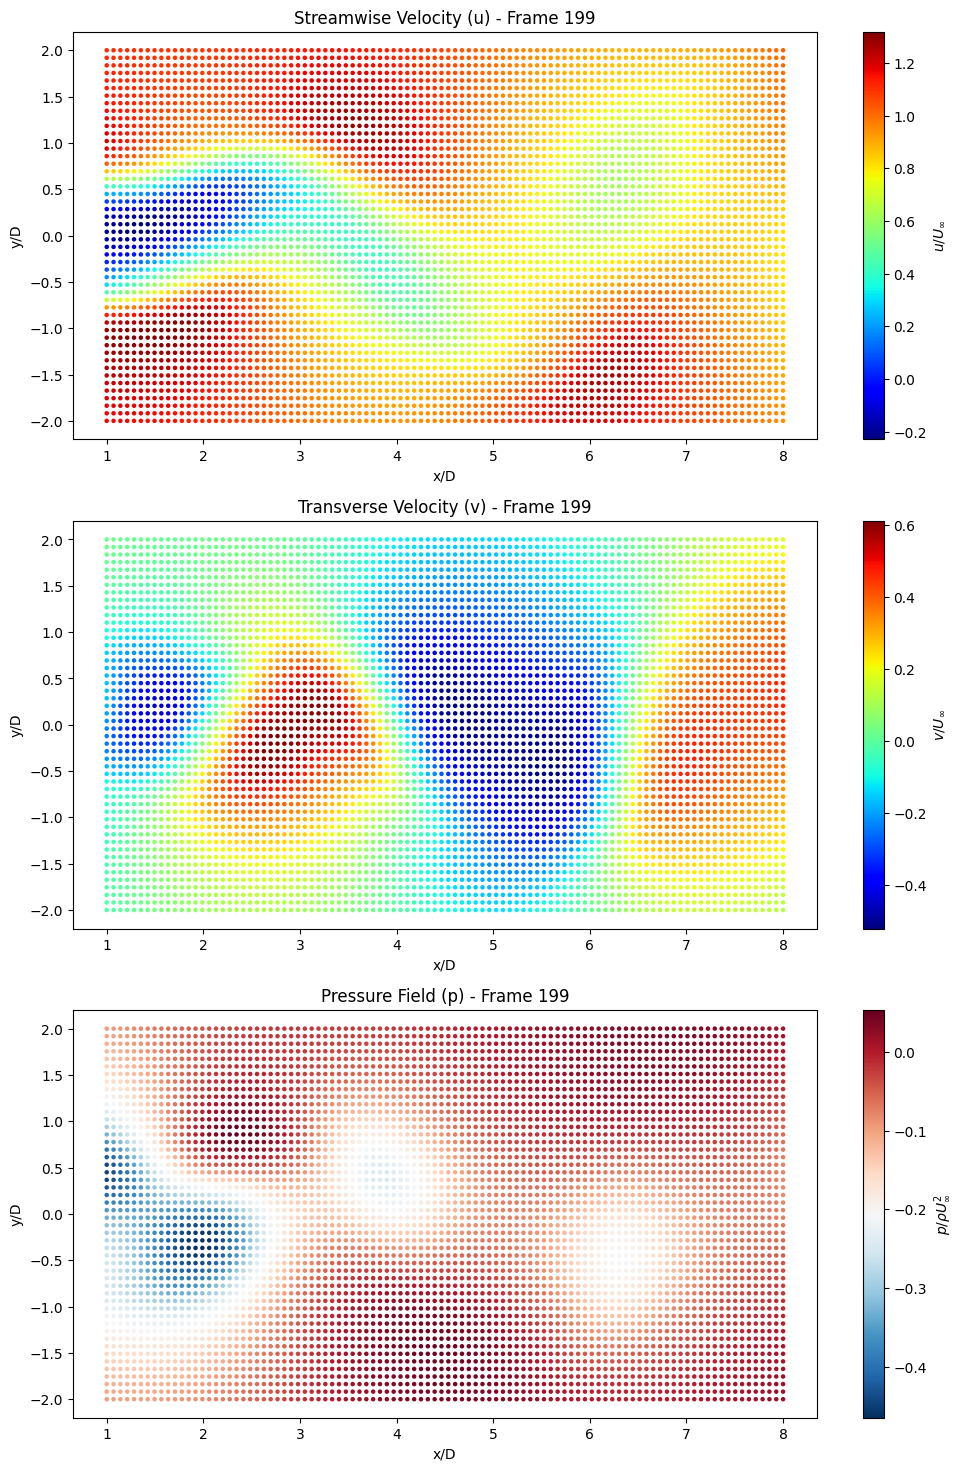

In [ ]:
# Plotting the data: 
# asymmetrical vortex shedding pattern in the cylinder wake (Kármán vortex street)

plt.figure(figsize=(12, 18))

# Streamwise Velocity u (normalized by U_inf = 1)
plt.subplot(3, 1, 1)
plt.scatter(x, y, c=u, s=5, cmap='jet')
plt.colorbar(label='$u / U_{\infty}$')
plt.title(f"Streamwise Velocity (u) - Frame {frame_idx}")
plt.xlabel("x/D")
plt.ylabel("y/D")

# Transverse Velocity v (normalized by U_inf = 1)
plt.subplot(3, 1, 2)
plt.scatter(x, y, c=v, s=5, cmap='jet')
plt.colorbar(label='$v / U_{\infty}$')
plt.title(f"Transverse Velocity (v) - Frame {frame_idx}")
plt.xlabel("x/D")
plt.ylabel("y/D")

# Pressure Field p (recovered up to a constant), 
# consistent with NS in Eq. 15 (implicitly includes the 1/rho factor) [Raissi et al., 2019, p. 695]
plt.subplot(3, 1, 3)
plt.scatter(x, y, c=p, s=5, cmap='RdBu_r')
plt.colorbar(label=r'$p / \rho U_{\infty}^2$') 
plt.title(f"Pressure Field (p) - Frame {frame_idx}")
plt.xlabel("x/D")
plt.ylabel("y/D")

plt.show()

### 2. Data Transformation for CNN (Grid Interpolation)

To facilitate the use of Convolutional Neural Networks (CNNs) and Convolutional Autoencoders (CAEs), the scattered spatial data is interpolated onto a structured Cartesian grid:

$$(u, v, p) \rightarrow (C, H, W)$$

This transformation converts physical fields  in into multi-channeled, image-like tensors, enabling the model to learn local spatial correlations and flow structures through convolutional filters.

In [4]:
import numpy as np

# numpy.min returns the minimum of an array or minimum along an axis
# numpy.max returns the maximum of an array or minimum along an axis
# We want extreme simulation values to interpolate over for our grid
x_min = np.min(x)
x_max = np.max(x)
y_min = np.min(y)
y_max = np.max(y)

print(f"x_min: {x_min}")
print(f"x_max: {x_max}")
print(f"y_min: {y_min}")
print(f"y_max: {y_max}")

# Transforming the data into regular 2D grid
np.meshgrid()

x_min: 1.0
x_max: 8.0
y_min: -2.0
y_max: 2.0


()

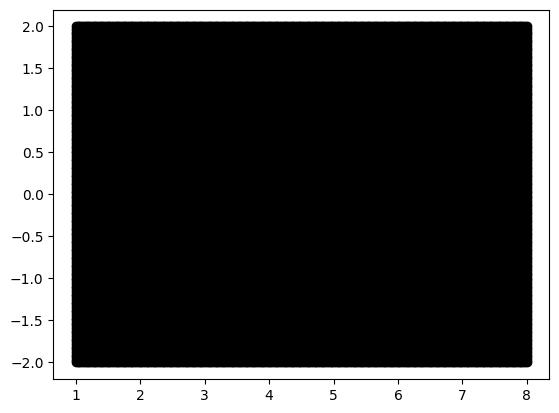

In [5]:
# Grid resolution for CNN
H = 128 # Height
W = 256 # Width

x_lin = np.linspace(x_min, x_max, W)
y_lin = np.linspace(y_min, y_max, H)

# Vectorized grid (grid of coordinates)
xv, yv = np.meshgrid(x_lin, y_lin) # Untupled

plt.plot(xv, yv, marker='o', color='k')
plt.show()

In [6]:
# DON'T RUN THIS CELL AGAIN

from scipy.interpolate import griddata

frames = 200
data_processed = np.zeros((frames, 3, H, W))

for frame in range(frames):
    u_raw = data_raw['U_star'][:, 0, frame]
    v_raw = data_raw['U_star'][:, 1, frame]
    p_raw = data_raw['p_star'][:, frame]

    u_grid = griddata(X_star, u_raw, (xv, yv), method='cubic')
    v_grid = griddata(X_star, v_raw, (xv, yv), method='cubic')
    p_grid = griddata(X_star, p_raw, (xv, yv), method='cubic')

    # Saving
    data_processed[frame, 0, :, :] = u_grid
    data_processed[frame, 1, :, :] = v_grid
    data_processed[frame, 2, :, :] = p_grid

In [7]:
import os

# Saving processed data to working directory
output_dir = '../data/processed'
file_path = os.path.join(output_dir, 'cylinder_nektar_wake.npy')
os.makedirs(output_dir, exist_ok=True)
np.save(file_path, data_processed.astype(np.float32))

### 3. Processed Data Verification

In [8]:
# Loading processed data file
data_processed_path = '../data/processed/cylinder_nektar_wake.npy'
data_processed = np.load(data_processed_path)

# Dimensionality check
print(f"Dataset shape: {data_processed.shape}")
print(f"Data type: {data_processed.dtype}")

Dataset shape: (200, 3, 128, 256)
Data type: float32


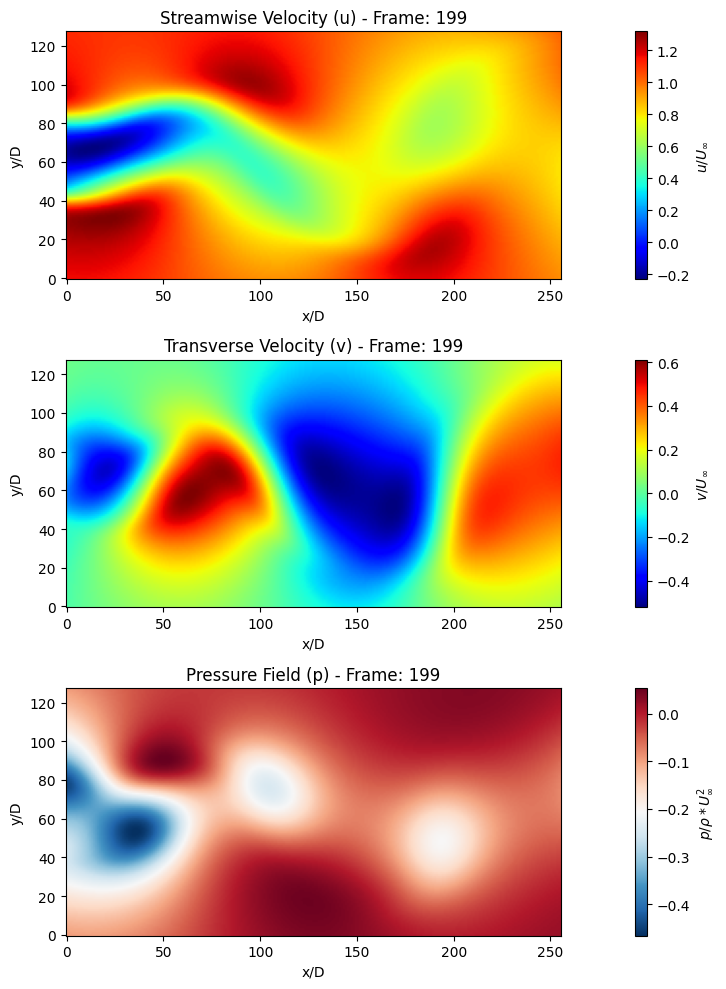

In [ ]:
channels = ['Streamwise Velocity (u)', 'Transverse Velocity (v)', 'Pressure Field (p)']
cmaps = ['jet', 'jet', 'RdBu_r']
units = ['$u / U_{\infty}$', '$v / U_{\infty}$', r'$p / \rho * U_{\infty}^2$'] # Non-dimensional units

plt.figure(figsize=(15, 10))

for i in range(3):
    plt.subplot(3, 1, i+1)
    plt.imshow(data_processed[frame_idx, i, :, :], cmap=cmaps[i], origin='lower')
    plt.colorbar(label=units[i])
    plt.title(f"{channels[i]} - Frame: {frame_idx}")
    plt.xlabel("x/D")
    plt.ylabel("y/D")
    
plt.tight_layout() # Prevent overlap
plt.show()

### 4. Data Normalization for CNN

To ensure stable convergence and prevent gradient saturation, the grid dataset is scaled using **Min-Max transformation**. This procedure is necessary for hyperbolic tangent activation functions used in original setup [Raissi et al., 2019, p. 687]. 

The standard min-max scaling formula for range $[0, 1]$ takes form of:

$$x' = \frac{x - \text{min}(x)}{\text{max}(x) - \text{min}(x)}$$

Since *tanh* is most sensitive within the $[-1, 1]$ range, scaling the input and target fields prevents the neurons from entering the saturation regions, where gradients vanish.
The normalization applied on a per-channel basis ($u, v, p$) using the transformed formula:

$$x' = 2 \cdot \frac{x - \text{min}(x)}{\text{max}(x) - \text{min}(x)} - 1$$

In [ ]:
# Calculating global extrema for each physical field (channel)
channel_min = data_processed.min(axis=(0, 2, 3), keepdims=True)
channel_max = data_processed.max(axis=(0, 2, 3), keepdims=True)

for i, name in enumerate(['u', 'v', 'p']):
    print(f"Global range for {name}: [{channel_min[0, i, 0, 0]}, {channel_max[0, i, 0, 0]}]")

Global range for u: [-0.24114370346069336, 1.3228373527526855]
Global range for v: [-0.6248636841773987, 0.6244580149650574]
Global range for p: [-0.536561906337738, 0.07260050624608994]


In [11]:
import json

stats = {
    "u": {"min": -0.24114370346069336, "max": 1.3228373527526855},
    "v": {"min": -0.6248636841773987, "max": 0.6244580149650574},
    "p": {"min": -0.536561906337738, "max": 0.07260050624608994}
}

# Save stats to a file
with open('../data/processed/normalization_stats.json', 'w') as f:
    json.dump(stats, f)

data_processed_norm = np.zeros_like(data_processed)
channels = ['u', 'v', 'p']

for i, ch in enumerate(channels):
    ch_min = stats[ch]['min']
    ch_max = stats[ch]['max']

    # Scaling 4D tensor (Time, Channels, Height, Width) to range [-1, 1] per channel
    # Min-Max Scaling: x_norm = 2 * (x - min) / (max - min) - 1
    data_processed_norm[:, i, :, :] = 2 * (data_processed[:, i, :, :] - ch_min) / (ch_max - ch_min) - 1

In [12]:
# Saving normalized data
norm_data_path = '../data/processed/cylinder_nektar_wake_norm.npy'
np.save(norm_data_path, data_processed_norm)
print(f"Normalized dataset saved at: {norm_data_path}")

Normalized dataset saved at: ../data/processed/cylinder_nektar_wake_norm.npy


In [13]:
# Loading normalized data
data_processed_norm_path = '../data/processed/cylinder_nektar_wake_norm.npy'
data_processed_norm = np.load(data_processed_norm_path)

In [14]:
# Verification of norm
for i, ch in enumerate(channels):
    ch_min = data_processed_norm[:, i, :, :].min()
    ch_max = data_processed_norm[:, i, :, :].max()
    print(f"{ch} norm: min = {ch_min}, max = {ch_max}")

u norm: min = -1.0, max = 1.0
v norm: min = -1.0, max = 1.0
p norm: min = -1.0, max = 1.0


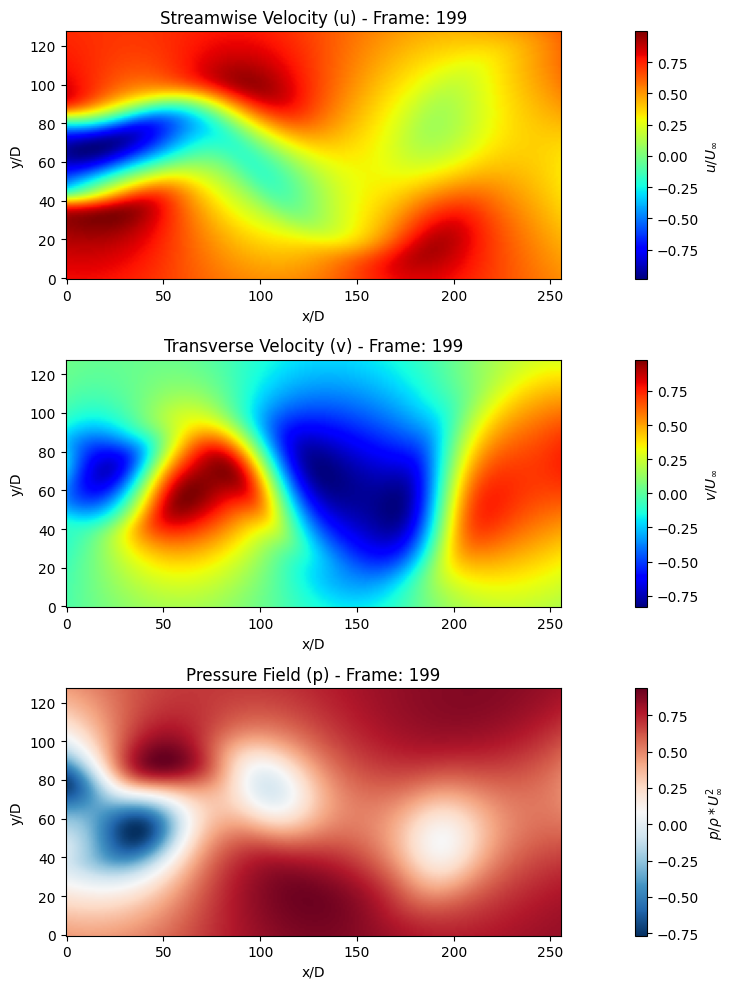

In [ ]:
# Plotting Normalized Data

channels = ['Streamwise Velocity (u)', 'Transverse Velocity (v)', 'Pressure Field (p)']
cmaps = ['jet', 'jet', 'RdBu_r']
units = ['$u / U_{\infty}$', '$v / U_{\infty}$', r'$p / \rho * U_{\infty}^2$'] # Non-dimensional units

plt.figure(figsize=(15, 10))

for i in range(3):
    plt.subplot(3, 1, i+1)
    plt.imshow(data_processed_norm[frame_idx, i, :, :], cmap=cmaps[i], origin='lower')
    plt.colorbar(label=units[i])
    plt.title(f"{channels[i]} - Frame: {frame_idx}")
    plt.xlabel("x/D")
    plt.ylabel("y/D")
    
plt.tight_layout() # Prevent overlap
plt.show()